In [9]:
# Imports
from astropy.table import Table
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

In [6]:
# Read VOT file from query
file_path = "data/ngc362_astr5140_wyz5rge-result.vot"  # change if needed

# Read as Astropy table
table = Table.read(file_path)

# print(table)
# print(len(table))

# Convert to pandas
df = table.to_pandas()

print(df.head())
print(df.columns)

             SOURCE_ID         ra        dec  parallax  parallax_error  \
0  4690603362443889792  15.934139 -71.346349  0.096548        0.260422   
1  4690603366746232192  15.913384 -71.341228  0.216941        0.108877   
2  4690603431163391360  15.897498 -71.336370 -0.050133        0.173684   
3  4690603431163393024  15.910591 -71.334075 -0.078073        0.271482   
4  4690603912199718528  15.707385 -71.341805 -0.048383        0.097834   

        pmra  pmra_error     pmdec  pmdec_error  phot_g_mean_mag  \
0  -0.594375    0.253857 -1.660841     0.265577        19.179611   
1  11.523517    0.114568  1.518508     0.114977        17.970472   
2   0.352691    0.184003 -1.212226     0.190410        18.542339   
3   1.076076    0.277447 -1.281891     0.294585        19.315510   
4   0.898562    0.108275 -1.252751     0.102734        17.837690   

   phot_bp_mean_mag  phot_rp_mean_mag     bp_rp      ruwe  radial_velocity  \
0         19.416954         18.571383  0.845572  1.014365           

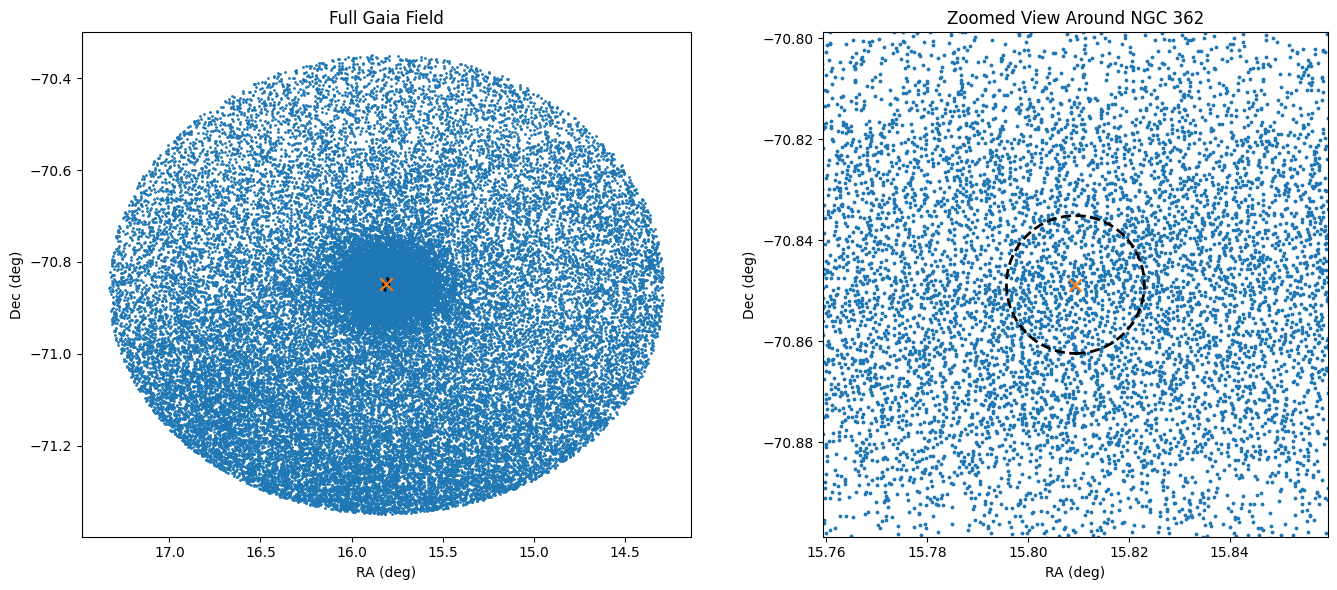

In [16]:
# Sanity check plots

# NGC 362 center (degrees)
ra_center = 15.8094167
dec_center = -70.8487778

# Half-light radius in degrees
r_h_arcmin = 0.82
r_h_deg = r_h_arcmin / 60.0

# Full field radius)
full_radius_deg = 0.5   # 30 arcmin

# Zoom radius for right panel
zoom_radius_deg = 0.05  # 3 arcmin

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------
# Left panel: full field
# -------------------------
ax = axes[0]
ax.scatter(df['ra'], df['dec'], s=1)

circle_full = Circle((ra_center, dec_center), r_h_deg,
                     fill=False, linewidth=2, linestyle='--')
ax.add_patch(circle_full)

ax.scatter(ra_center, dec_center, marker='x', s=80)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Full Gaia Field")
ax.invert_xaxis()

# -------------------------
# Right panel: zoomed view
# -------------------------
ax = axes[1]
ax.scatter(df['ra'], df['dec'], s=3)

circle_zoom = Circle((ra_center, dec_center), r_h_deg,
                     fill=False, linewidth=2, linestyle='--')
ax.add_patch(circle_zoom)

ax.scatter(ra_center, dec_center, marker='x', s=80)

ax.set_xlim(ra_center + zoom_radius_deg, ra_center - zoom_radius_deg)
ax.set_ylim(dec_center - zoom_radius_deg, dec_center + zoom_radius_deg)

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Zoomed View Around NGC 362")
ax.invert_xaxis()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()